# Noise, simulating it, and comparing performance of codes and decoders
For now let's assume just a binary channel made of 0s and 1s.

With some probability $\epsilon_0$, we apply a NOT gate to a logical $0$, and with some probability $\epsilon_1$ we apply a NOT gate to a logical $1$. If these probabilities are the same, we say this is a Binary Symmetric Channel (BSC).

Let's assume a BSC, and plot the output bit error rate, for an input (sometimes physical) error rate $\epsilon$. We're expecting it to be the identity function (since we're not correcting any errors), but it's a good excercise that we will build on later.

To do that we will:
1. Randomize a vector of $1,000$ bits, call these the data bits. Then 
2. For every $\epsilon$ in some range, say $0.1, 0.01, 0.001, 0.0001$ we will:
3. Randomize another vector of $1,000$ bits, which has probability of $\epsilon$ to have $1$ in each coordinate, and XOR it with the data bits. Finally
4. Compare the original data bits to the corrupt data bits, and count how many are different. Divide by $1,000$ to get an avergae.
5. Plot the average as a function of $\epsilon$





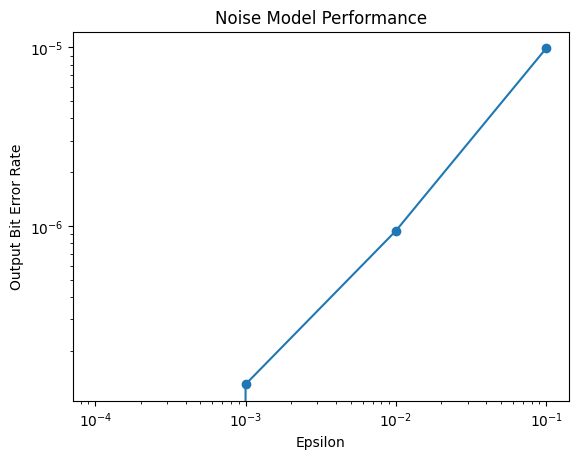

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
epsilonRange = [0.1, 0.01, 0.001, 0.0001]
outputBitErrorRates = []
data = np.random.randint(0, 2, size=(10000, 1))
for epsilon in epsilonRange:
    noise = np.random.choice([0,1], size=(10000, 1), p=[1-epsilon, epsilon])
    corruptData = (data + noise)%2
    errorRate = np.sum(np.mean(corruptData != data)) / len(data)
    outputBitErrorRates.append(errorRate)


fig, ax = plt.subplots()
ax.plot(epsilonRange, outputBitErrorRates, 'o-')
ax.set_xlabel('Epsilon')
ax.set_ylabel('Output Bit Error Rate')
ax.set_title('Noise Model Performance')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

Some notes:
1. I plotted everything on log-log scale (so log of x axis and log of y axis).
2. Not sure why, but in the qecc community the plots work so higher physical error rate is on the right and decreasing as you look left. In the classical ECC community it's usually flipped so as you go to the right the error rate decreases.


Terms to cover in this notebook:

✅Binary Symmetric Channel

❌Depolarizing channel

❌Hellinger fidelity